# Plots of deterministic results

In [2]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import scipy.special as sps

In [3]:
#set serif font
plt.rcParams["font.family"]="serif"

In [4]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#E0D432", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

## Rate constants

In [5]:
R = 0.00888
K = 0.00772

## $\frac{F_{fast}}{A}$ plot vs. $\frac{N}{A}$

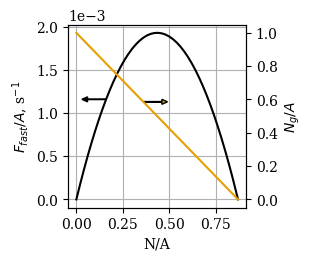

In [6]:
density = np.arange(0, K/R, 0.02)
density[-1] = K/R

T = np.arange(0, 3601, 50)
T[0] = 1 #can't have T=0 because that will result in division by 0

F_fastA = density*R - density**2 * R**2 / K
X_g = 1-density*R/K

for i in range(0, F_fastA.size):
    if F_fastA[i] < 0:
        F_fastA[i]=0

f, ax = plt.subplots(layout="constrained", figsize=(3,2.5))

pt1 = ax.plot(density, F_fastA)
pt1[0].set_color(wong_colors[0])

ax.set_xlabel("N/A")
ax.set_ylabel("$F_{fast}/A$, s$^{-1}$")
ax.grid(True)

ax.ticklabel_format(scilimits=(-2,5))

ax.arrow(density[8], F_fastA[8], -0.1, 0,
         width=0.003*(F_fastA.max()-F_fastA.min()),
         head_width=0.03*(F_fastA.max()-F_fastA.min()),
         head_length=0.03,
         facecolor=wong_colors[0])

ax2 = ax.twinx()

pt2 = ax2.plot(density, X_g)
pt2[0].set_color(wong_colors[1])

ax2.set_ylabel("$N_g/A$")

ax2.arrow(density[18], X_g[18], 0.1, 0,
         width=0.003*(X_g.max()-X_g.min()),
         head_width=0.03*(X_g.max()-X_g.min()),
         head_length=0.03,
         facecolor=wong_colors[1])

#plt.show()
plt.savefig("f_fast.pdf")

## $\frac{F_{slow}}{A}$ plot vs. $\frac{N}{A}$ and $T$

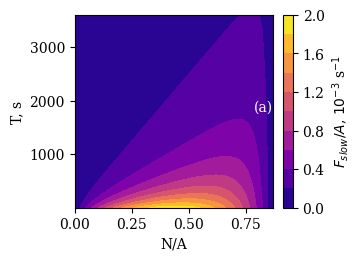

In [11]:
dd, TT = np.meshgrid(density, T)

F_slowA = dd*(1 - np.exp(-TT*R + TT*R**2*dd/K))/TT

f, ax = plt.subplots(layout="constrained", figsize=(3.5,2.5))

im_ptr = ax.contourf(dd, TT, F_slowA*1000, levels=10, cmap="plasma")

cb = plt.colorbar(im_ptr, ax=ax, label="$F_{slow}/A$, $10^{-3}$ s$^{-1}$")
cb.formatter.set_powerlimits((-1, 5))

ax.set_xlabel("N/A")
ax.set_ylabel("T, s")

ax.annotate("(a)", (0.9, 0.5), xycoords="axes fraction", color="white")

#plt.show()
plt.savefig("f_slow_contour.pdf")

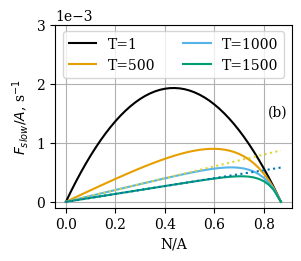

In [9]:
f, ax = plt.subplots(layout="constrained", figsize=(2.9,2.5))

ax.set_prop_cycle(wong_cycle)

ax.plot(density, F_slowA[0,0:], "-", label="T={0:.0f}".format(T[0]))
ax.plot(density, F_slowA[10,0:], "-", label="T={0:.0f}".format(T[10]))
ax.plot(density, F_slowA[20,0:], "-", label="T={0:.0f}".format(T[20]))
ax.plot(density, F_slowA[30,0:], "-", label="T={0:.0f}".format(T[30]))

ax.plot(density, density/1000, ":")
ax.plot(density, density/1500, ":")

ax.set_xlabel("N/A")
ax.set_ylabel("$F_{slow}/A$, s$^{-1}$")
ax.set_ylim([-0.0001, 0.003])
ax.legend(ncols=2, loc="upper center")

ax.grid(True)

ax.annotate("(b)", (0.9, 0.5), xycoords="axes fraction")

ax.ticklabel_format(scilimits=(-2,5))

#plt.show()
plt.savefig("f_slow_na_t.pdf")

## Optimal sheep density vs T for slow farmer

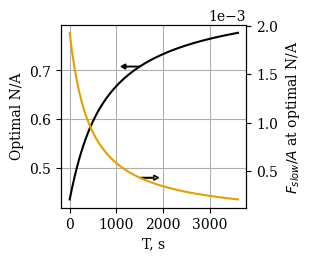

In [72]:
f, ax = plt.subplots(layout="constrained", figsize=(3,2.5))

N_opt = np.real(K*(sps.lambertw(np.exp(T*R+1))-1)/(T*R**2))
pt1 = ax.plot(T, N_opt,"-")
pt1[0].set_color(wong_colors[0])

ax.set_xlabel("T, s")
ax.set_ylabel("Optimal N/A")
ax.grid(True)
ax.arrow(T[30], N_opt[30], -300, 0,
         width=0.003*(N_opt.max()-N_opt.min()),
         head_width=0.03*(N_opt.max()-N_opt.min()),
         head_length=100,
         facecolor=wong_colors[0])

ax2=ax.twinx()

F_slowA = np.real(K*(sps.lambertw(np.exp(T*R+1))-1)*(1-np.exp(-T*R+sps.lambertw(np.exp(T*R+1))-1))/(R**2*T**2))
pt2 = ax2.plot(T, F_slowA) #darkorange is the default second plot color
pt2[0].set_color(wong_colors[1])

ax2.set_ylabel("$F_{slow}/A$ at optimal N/A")
ax2.ticklabel_format(scilimits=(-1,5))
ax2.arrow(T[30], F_slowA[30], 300, 0,
          width=0.003*(F_slowA.max()-F_slowA.min()),
          head_width=0.03*(F_slowA.max()-F_slowA.min()),
          head_length=100,
          facecolor=wong_colors[1])

#plt.show()
plt.savefig("optimal_na.pdf")